# This notebook will be divided into four parts:
### 1) Data Collection
### 2) Data Cleaning & Handling Null Values 
### 3) EDA
### 4) Exporting the modified data for model training

#### --------------------------------------------------------------------------------------------------------------------------------

## 1) Data Collection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('train.csv')

In [3]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


#### ------------------------------------------------------------------------------------------------------------------------------------------

## 2) Data Cleaning & Handling Missing Values

In [5]:
df=df.drop("Id",axis=1)

In [6]:
df[df.duplicated()]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   str    
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   str    
 5   Alley          91 non-null     str    
 6   LotShape       1460 non-null   str    
 7   LandContour    1460 non-null   str    
 8   Utilities      1460 non-null   str    
 9   LotConfig      1460 non-null   str    
 10  LandSlope      1460 non-null   str    
 11  Neighborhood   1460 non-null   str    
 12  Condition1     1460 non-null   str    
 13  Condition2     1460 non-null   str    
 14  BldgType       1460 non-null   str    
 15  HouseStyle     1460 non-null   str    
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt      1460

In [8]:
df.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'Wo

In [9]:
features_with_na=[features for features in df.columns if df[features].isnull().sum()>=1]
for feature in features_with_na:
    print(feature,df[feature].isnull().sum(), "missing value")

LotFrontage 259 missing value
Alley 1369 missing value
MasVnrType 872 missing value
MasVnrArea 8 missing value
BsmtQual 37 missing value
BsmtCond 37 missing value
BsmtExposure 38 missing value
BsmtFinType1 37 missing value
BsmtFinType2 38 missing value
Electrical 1 missing value
FireplaceQu 690 missing value
GarageType 81 missing value
GarageYrBlt 81 missing value
GarageFinish 81 missing value
GarageQual 81 missing value
GarageCond 81 missing value
PoolQC 1453 missing value
Fence 1179 missing value
MiscFeature 1406 missing value


1. LotFrontage median value,
2. Alley mode,
3. MasVnrType mode,
4. MasVnrArea median,
5. BsmtQual mode,
6. BsmtCond mode,
7. BsmtExposure mode,
8. BsmtFinType1 mode,
9. BsmtFinType2 mode,
10. Electrical mode,
11. FireplaceQu mode,
12. GarageType mode,
13. GarageYrBlt median,
14. GarageFinish mode,
15. GarageQual mode,
16. GarageCond mode,
17. PoolQC mode,
18. Fence mode,
19. MiscFeature mode

In [10]:
df['LotFrontage']=df['LotFrontage'].fillna(df['LotFrontage'].median())

In [11]:
df['Alley']=df['Alley'].fillna(df['Alley'].mode()[0])

In [12]:
df['MasVnrType']=df['MasVnrType'].fillna(df['MasVnrType'].mode()[0])
df['MasVnrArea']=df['MasVnrArea'].fillna(df['MasVnrArea'].median())
df['BsmtQual']=df['BsmtQual'].fillna(df['BsmtQual'].mode()[0])
df['BsmtCond']=df['BsmtCond'].fillna(df['BsmtCond'].mode()[0])
df['BsmtExposure']=df['BsmtExposure'].fillna(df['BsmtExposure'].mode()[0])
df['BsmtFinType1']=df['BsmtFinType1'].fillna(df['BsmtFinType1'].mode()[0])
df['BsmtFinType2']=df['BsmtFinType2'].fillna(df['BsmtFinType2'].mode()[0])
df['Electrical']=df['Electrical'].fillna(df['Electrical'].mode()[0])
df['FireplaceQu']=df['FireplaceQu'].fillna(df['FireplaceQu'].mode()[0])
df['GarageType']=df['GarageType'].fillna(df['GarageType'].mode()[0])
df['GarageYrBlt']=df['GarageYrBlt'].fillna(df['GarageYrBlt'].mode()[0])
df['GarageFinish']=df['GarageFinish'].fillna(df['GarageFinish'].mode()[0])
df['GarageQual']=df['GarageQual'].fillna(df['GarageQual'].mode()[0])
df['GarageCond']=df['GarageCond'].fillna(df['GarageCond'].mode()[0])
df['PoolQC']=df['PoolQC'].fillna(df['PoolQC'].mode()[0])
df['Fence']=df['Fence'].fillna(df['Fence'].mode()[0])
df['MiscFeature']=df['MiscFeature'].fillna(df['MiscFeature'].mode()[0])

In [13]:
df.isnull().sum()

MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
Street           0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 80, dtype: int64

#### ------------------------------------------------------------------------------------------------------------------------------------------

## 3) EDA

<Axes: >

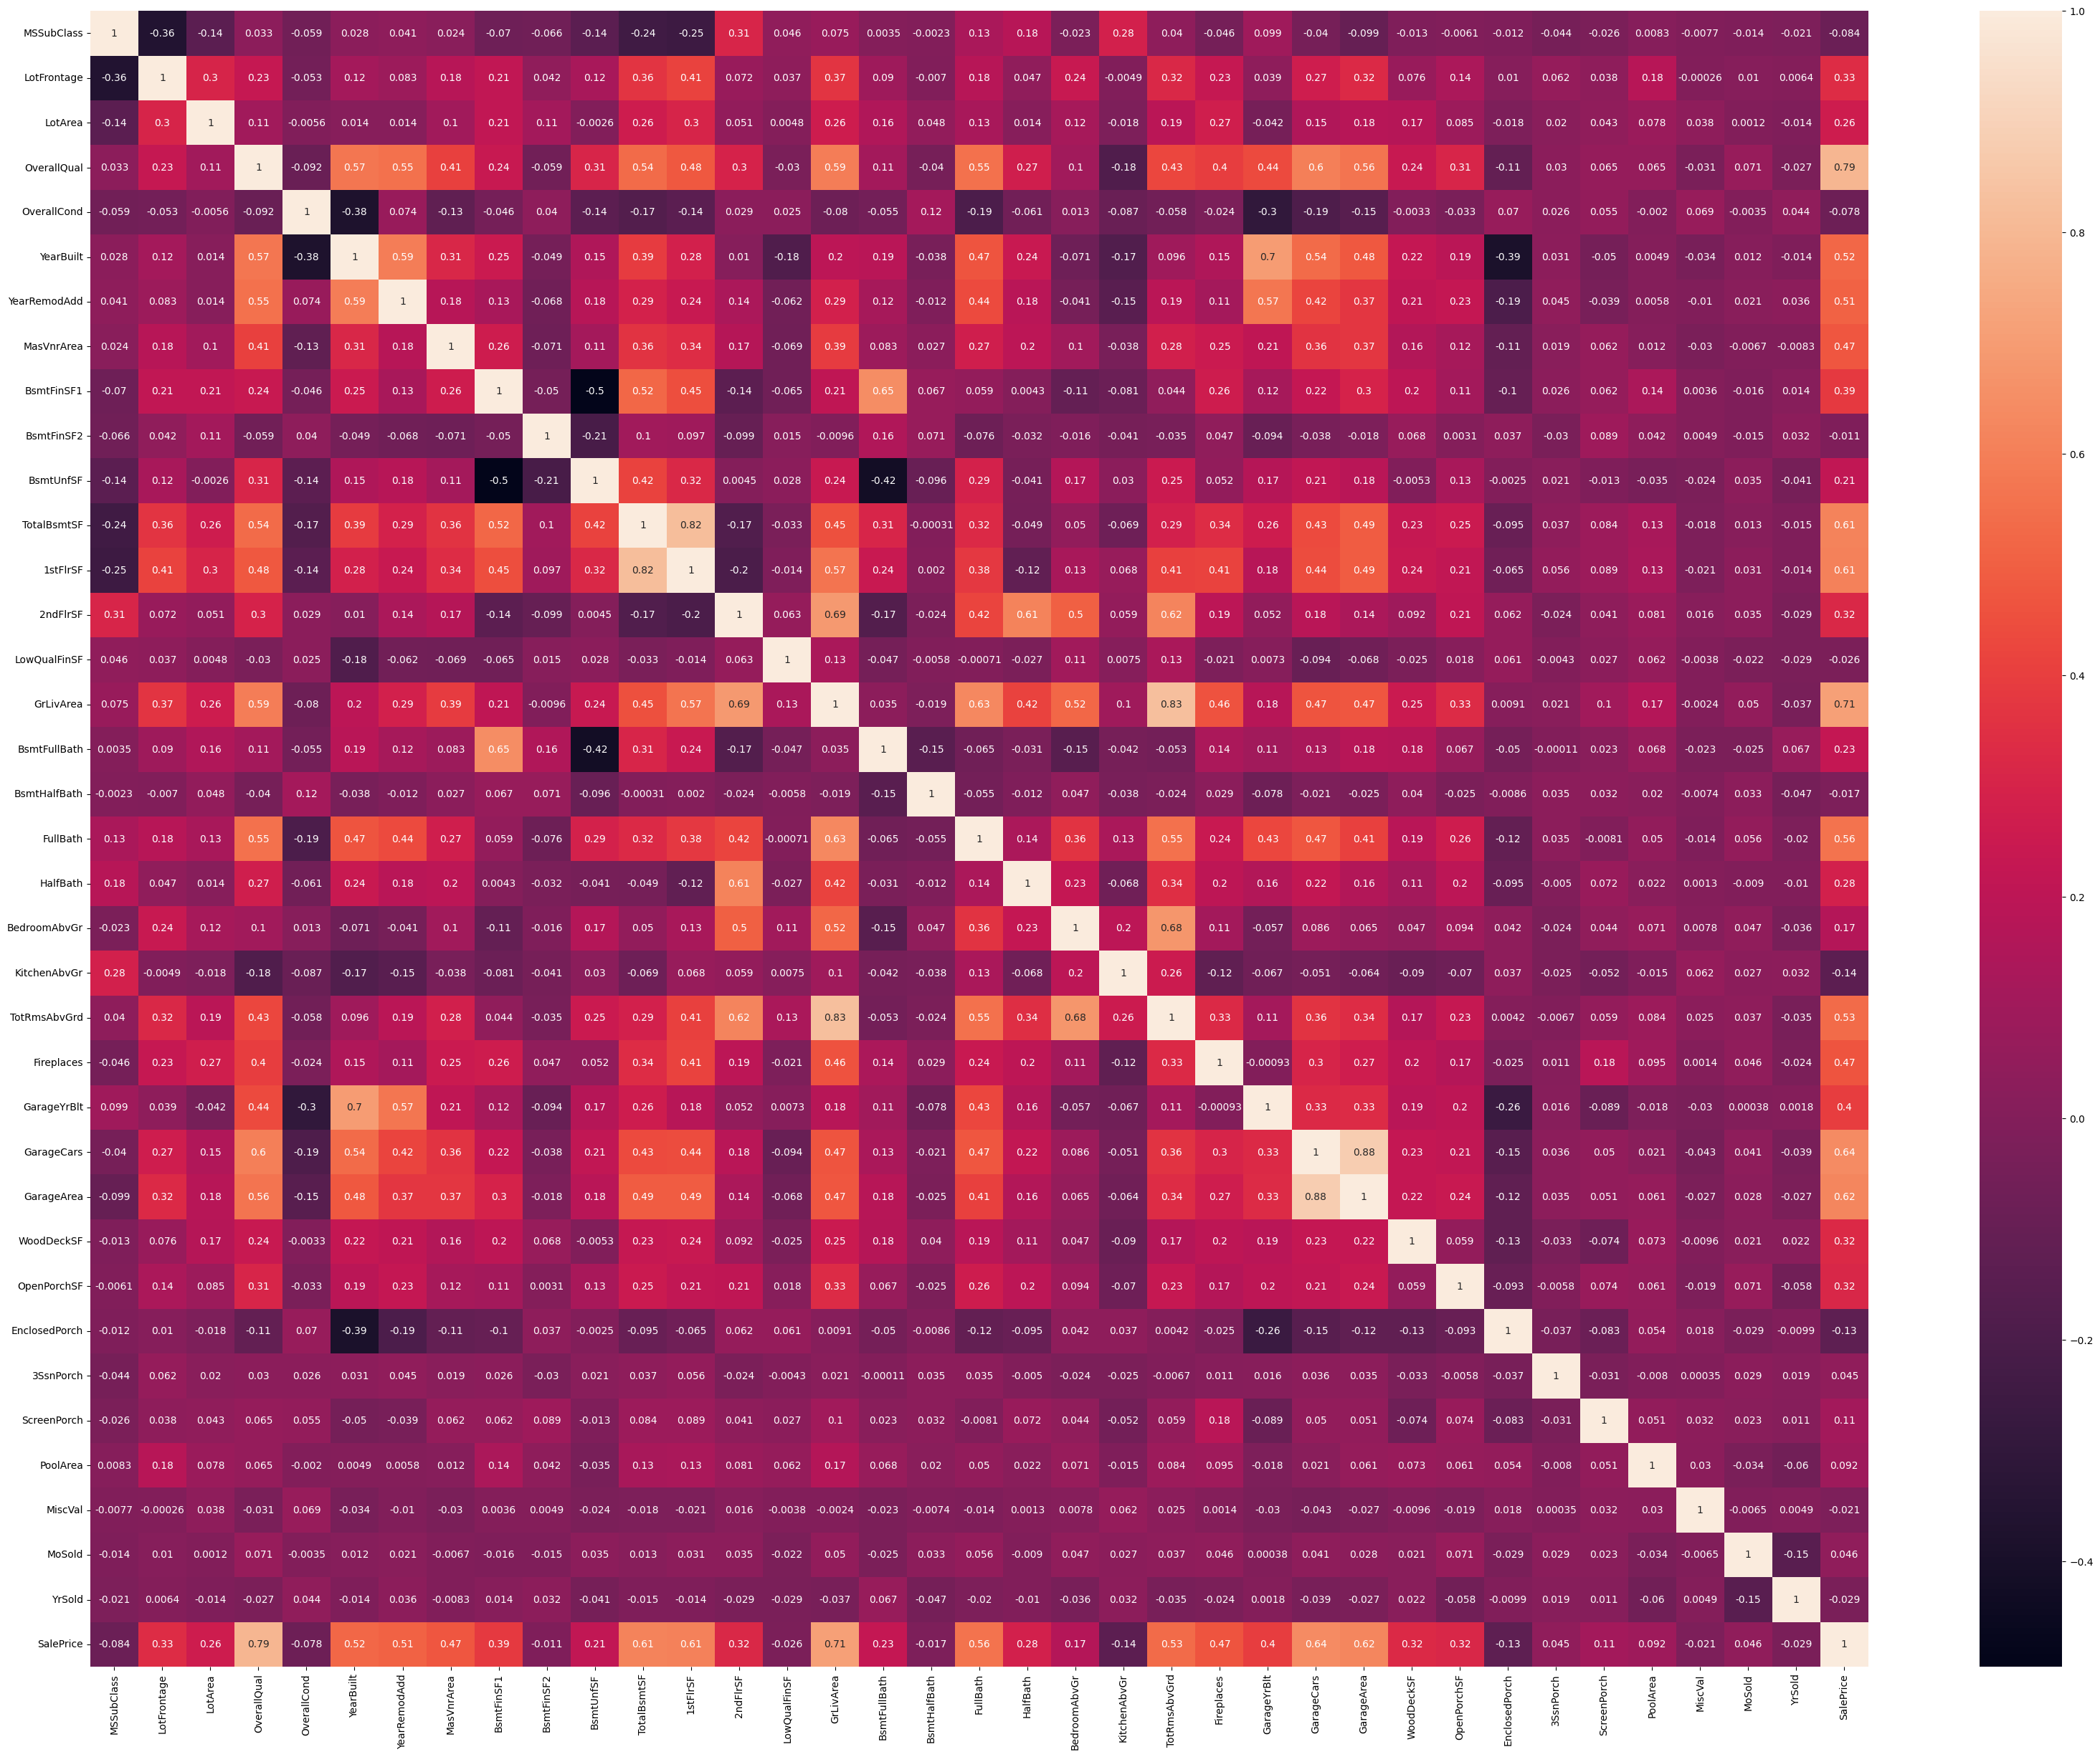

In [14]:
plt.figure(figsize=(40,30))
sns.heatmap(df.corr(numeric_only=True),annot=True)

<Axes: xlabel='LotFrontage', ylabel='SalePrice'>

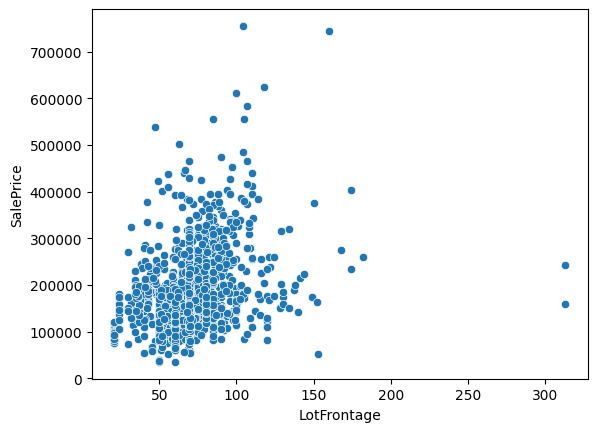

In [15]:
sns.scatterplot(data=df,x='LotFrontage',y='SalePrice')

The Price of the houses have a positive relation with the Linear feet of street connected to the property.

<Axes: xlabel='OverallQual', ylabel='SalePrice'>

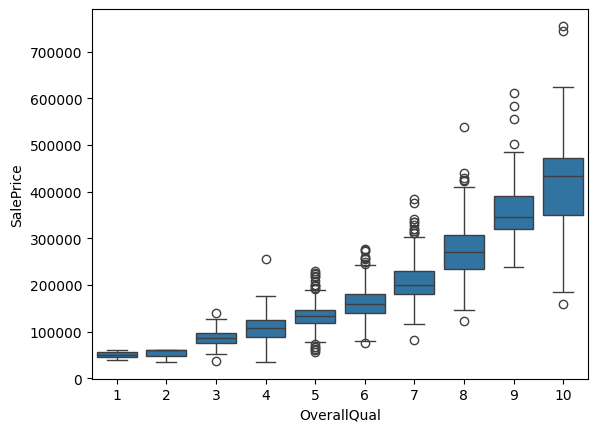

In [16]:
sns.boxplot(data=df,x='OverallQual',y='SalePrice')

The Sale Price has a good positive relation with the Overall Quality of the house which is obvious but there are many houses with good overall Quality but their prices are not what it should be.
The Sale price of a house depends on many variables so it might be because of that reason

<Axes: xlabel='TotalBsmtSF', ylabel='SalePrice'>

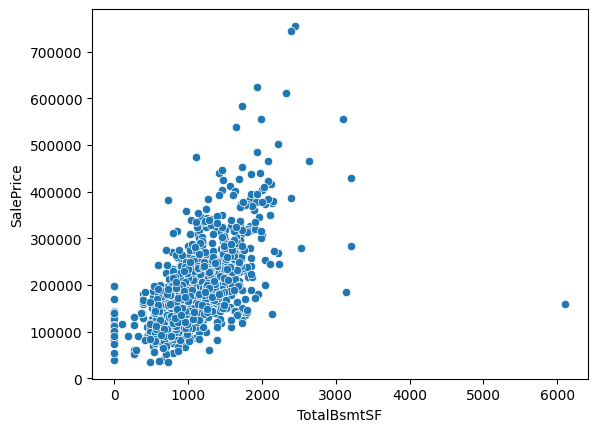

In [17]:
sns.scatterplot(data=df,x='TotalBsmtSF',y='SalePrice')

The size of Basement affects the Sales Price positively.

In [18]:
df['Neighborhood'].value_counts()

Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
StoneBr     25
SWISU       25
MeadowV     17
Blmngtn     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64

In [26]:
df.groupby('Neighborhood')[['SalePrice','OverallQual','GrLivArea','GarageCars','1stFlrSF']].min().sort_values(by='SalePrice',ascending=False)

,SalePrice,OverallQual,GrLivArea,GarageCars,1stFlrSF
Neighborhood,,,,,
NoRidge,190000,7,1624,2,979
StoneBr,170000,7,1088,2,1064
Veenker,162500,5,1208,2,1094
Blmngtn,159895,7,1145,2,1145
NridgHt,154000,6,1306,2,764
Somerst,144152,6,1102,2,520
Gilbert,141000,4,864,2,616
Timber,137500,5,1137,1,754
ClearCr,130000,4,988,0,616


1. Blmngtn	Bloomington Heights
2. Blueste	Bluestem
3. BrDale	Briardale
4. BrkSide	Brookside
5. ClearCr	Clear Creek
6. CollgCr	College Creek
7. Crawfor	Crawford
8. Edwards	Edwards
9. Gilbert	Gilbert
10. IDOTRR	Iowa DOT and Rail Road
11. MeadowV	Meadow Village
12. Mitchel	Mitchell
13. Names	North Ames
14. NoRidge	Northridge
15. NPkVill	Northpark Villa
16. NridgHt	Northridge Heights
17. NWAmes	Northwest Ames
18. OldTown	Old Town
19. SWISU	South & West of Iowa State University
20. Sawyer	Sawyer
21. SawyerW	Sawyer West
22. Somerst	Somerset
23. StoneBr	Stone Brook
24. Timber	Timberland
25. Veenker	Veenker

The houses in the regions Northridge, Northridge Heights, Stone Brook and Bloomington Heights are more expensive than the houses in other regions and the minimum size of the houses are also larger compared to other areas so we may consider that these areas are more lavish compared to other regions.

<Axes: xlabel='1stFlrSF', ylabel='SalePrice'>

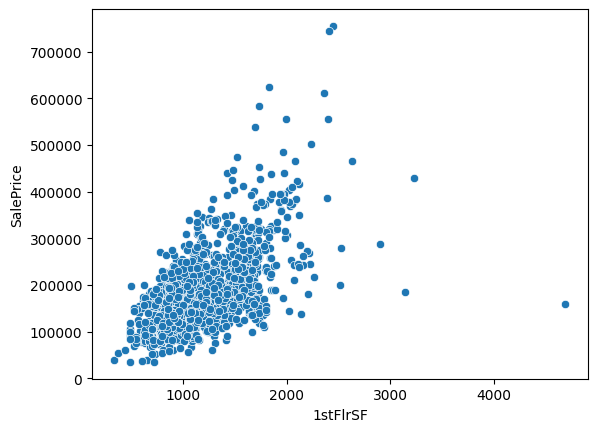

In [28]:
sns.scatterplot(data=df,x='1stFlrSF',y='SalePrice')

<Axes: xlabel='2ndFlrSF', ylabel='SalePrice'>

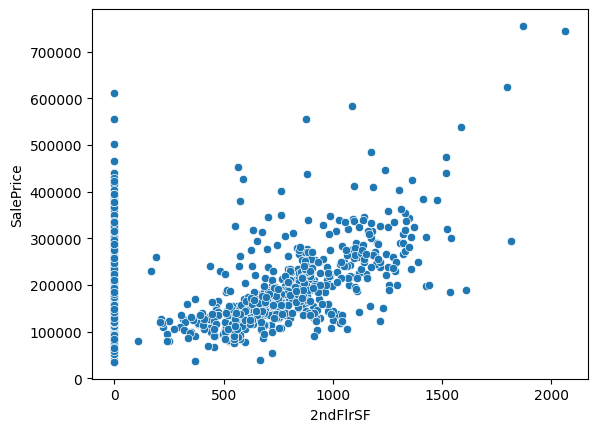

In [29]:
sns.scatterplot(data=df,x='2ndFlrSF',y='SalePrice')

The sales Price of the house increases, the increase in the area of 1st Floor and 2nd Floor directly affects the Sales Price in a positive way

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

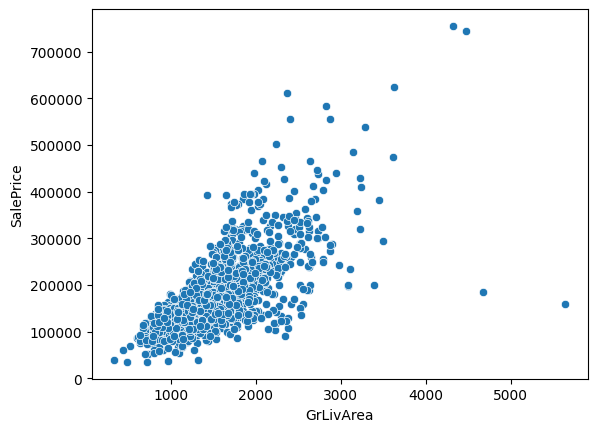

In [30]:
sns.scatterplot(data=df,x='GrLivArea',y='SalePrice')

The Ground Living Area Affects the Price in a good way which is obvious but there are some outliers with large Living area but they are not fetching the price they should, that maybe because of the Overall Quality of the house, Location and etc.

In [31]:
df['GarageCars'].value_counts()

GarageCars
2    824
1    369
3    181
0     81
4      5
Name: count, dtype: int64

<Axes: xlabel='GarageCars', ylabel='SalePrice'>

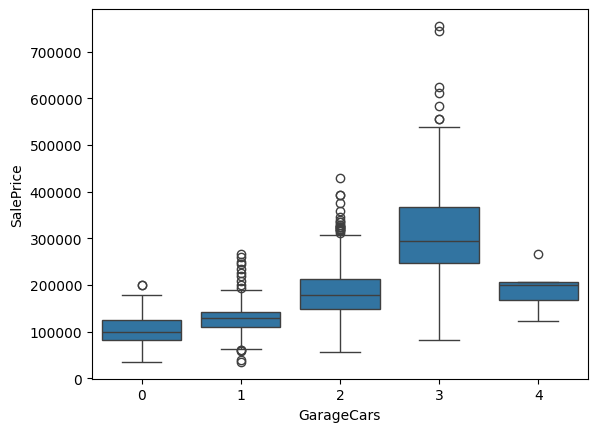

In [33]:
sns.boxplot(data=df,x='GarageCars',y='SalePrice')

The Sales Price obviously increases with the increase in the Garage cars

<Axes: xlabel='GarageArea', ylabel='SalePrice'>

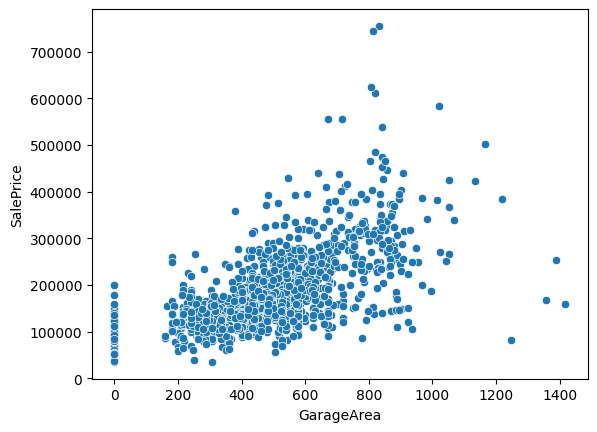

In [34]:
sns.scatterplot(data=df,x='GarageArea',y='SalePrice')

<Axes: xlabel='SalePrice', ylabel='Count'>

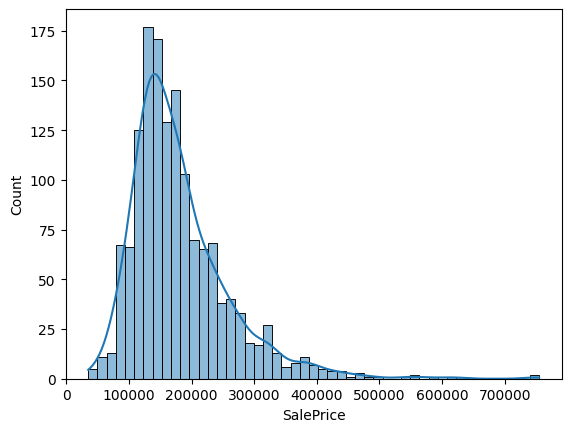

In [35]:
sns.histplot(df['SalePrice'],kde=True)

The Sale Price in this dataset is left skewed and most of the sales fall in the range below 400000

By analysing this dataset I found that the Sales Price of the houses depends on many features and we can't predict the behaviour of the graph and say the exact reason behind the less price of a property but one thing is certain that the price has a very good relationship with the Neighborhood

In [36]:
df.to_csv("modified_train.csv")